# DeepLabV3+ Binary Vertebra/Spine Pre-mask — Colab Notebook

Purpose: train a **non-YOLO semantic segmentation model** that predicts a rough binary spine/vertebra mask from AP scoliosis/frontal spine radiographs.

Target mask:
- `0 = background`
- `1 = any annotated vertebra/spine region`

This notebook uses multiclass ID masks (`0..17`) only as source masks, then converts them to binary with:

```python
binary_mask = (id_mask > 0).astype(np.uint8)
```

It prefers manually corrected masks when available and falls back to the original multiclass ID masks.

In [1]:
# ============================================================
# 1) Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [2]:
# ============================================================
# 2) Install required libraries
# ============================================================
!pip -q install --no-deps segmentation-models-pytorch timm efficientnet-pytorch pretrainedmodels

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.9 MB/s eta 0:00:00


In [3]:
# ============================================================
# 3) Imports and reproducibility
# ============================================================

from __future__ import annotations

import os
import json
import random
import shutil
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm



import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ============================================================
# 4) Configuration — all project paths in one place
# ============================================================

@dataclass
class CFG:
    seed: int = 42

    # Main project paths from previous work.
    PROJECT_BASE: Path = Path(
        "PATH_HERE"
    )
    DATASET_ROOT: Path = PROJECT_BASE / "Scoliosis_Dataset"
    YOLO_PROJECT_ROOT: Path = PROJECT_BASE / "yolo_vertebra_seg"
    TRAINING_RUNS_ROOT: Path = YOLO_PROJECT_ROOT / "training_runs"

    # Original image folders.
    NORMAL_DIR: Path = DATASET_ROOT / "Normal"
    SCOLIOSIS_DIR: Path = DATASET_ROOT / "Scoliosis"

    # Original multiclass ID masks.
    ORIGINAL_ID_MASK_DIR: Path = DATASET_ROOT / "LabelMultiClass_ID_PNG"

    # Corrected ID masks from your manual correction workflow.
    CORRECTED_ID_MASK_DIR: Path = DATASET_ROOT / "vertebra_mask_correction" / "outputs" / "LabelMultiClass_ID_PNG_corrected"

    # Optional dataset index used by the old notebook, if present.
    INDEX_CSV_PATH: Path = DATASET_ROOT / "indice_dataset.csv"

    # New images for final inference.
    # Change this one variable if your folder name changes.
    NEW_IMAGES_DIR: Path = PROJECT_BASE / "new_jpeg_images_for_binary_premask"

    # Experiment.
    EXPERIMENT_NAME: str = "deeplabv3plus_binary_spine_premask_effb4_seed42_thr06"
    ENCODER_NAME: str = "efficientnet-b4"   # Try "efficientnet-b4" if memory allows.
    ENCODER_WEIGHTS: str = "imagenet"
    ARCHITECTURE: str = "DeepLabV3Plus"

    # Training size.
    IMAGE_SIZE: int = 768  # Use 512/640 if out of memory; 1024 if memory allows.
    BATCH_SIZE: int = 2    # Increase to 4 if GPU memory allows.
    NUM_WORKERS: int = 2
    EPOCHS: int = 80
    PATIENCE: int = 15
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4

    # Validation split.
    VAL_SIZE: float = 0.15
    TEST_SIZE: float = 0.15

    # Cropping mode.
    # "full" = resize/pad full image.
    # "central" = safe central crop before resize/pad.
    CROP_MODE: str = "full"
    CENTRAL_CROP_WIDTH_FRAC: float = 0.72
    CENTRAL_CROP_HEIGHT_FRAC: float = 1.00

    # Loss weights.
    DICE_WEIGHT: float = 0.6
    FOCAL_WEIGHT: float = 0.4

    # Inference thresholds.
    THRESHOLDS: Tuple[float, ...] = (0.3, 0.4, 0.5, 0.6)
    DEFAULT_THRESHOLD: float = 0.6

    # Overlay.
    OVERLAY_ALPHA: float = 0.35
    BRIGHT_MASK_RGB: Tuple[int, int, int] = (242, 209, 12)  # Yellow, matches your first class palette.

cfg = CFG()

RUN_DIR = cfg.TRAINING_RUNS_ROOT / cfg.EXPERIMENT_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
PLOTS_DIR = RUN_DIR / "plots"
SAMPLE_VAL_DIR = RUN_DIR / "sample_validation_overlays"
SAMPLE_TEST_DIR = RUN_DIR / "sample_test_overlays"
INFERENCE_DIR = RUN_DIR / "inference_new_jpegs"

for p in [RUN_DIR, CHECKPOINT_DIR, PLOTS_DIR, SAMPLE_VAL_DIR, SAMPLE_TEST_DIR, INFERENCE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE        :", cfg.PROJECT_BASE)
print("DATASET_ROOT        :", cfg.DATASET_ROOT, "| exists:", cfg.DATASET_ROOT.exists())
print("YOLO_PROJECT_ROOT   :", cfg.YOLO_PROJECT_ROOT, "| exists:", cfg.YOLO_PROJECT_ROOT.exists())
print("TRAINING_RUNS_ROOT  :", cfg.TRAINING_RUNS_ROOT, "| exists:", cfg.TRAINING_RUNS_ROOT.exists())
print("NORMAL_DIR          :", cfg.NORMAL_DIR, "| exists:", cfg.NORMAL_DIR.exists())
print("SCOLIOSIS_DIR       :", cfg.SCOLIOSIS_DIR, "| exists:", cfg.SCOLIOSIS_DIR.exists())
print("ORIGINAL_ID_MASK_DIR:", cfg.ORIGINAL_ID_MASK_DIR, "| exists:", cfg.ORIGINAL_ID_MASK_DIR.exists())
print("CORRECTED_ID_MASK_DIR:", cfg.CORRECTED_ID_MASK_DIR, "| exists:", cfg.CORRECTED_ID_MASK_DIR.exists())
print("INDEX_CSV_PATH      :", cfg.INDEX_CSV_PATH, "| exists:", cfg.INDEX_CSV_PATH.exists())
print("NEW_IMAGES_DIR      :", cfg.NEW_IMAGES_DIR, "| exists:", cfg.NEW_IMAGES_DIR.exists())
print("RUN_DIR             :", RUN_DIR)

In [5]:
# ============================================================
# 5) Save config
# ============================================================

def path_to_str(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return list(obj)
    return obj

config_dict = {k: path_to_str(v) for k, v in asdict(cfg).items()}
config_path = RUN_DIR / "config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_dict, f, indent=2, ensure_ascii=False)

print("Saved config:", config_path)

Saved config: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/config.json


In [6]:
# ============================================================
# 6) Path helpers and image/mask discovery
# ============================================================

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"]
MASK_EXTS = [".png"]

ALLOWED_IDS = set(range(18))  # 0..17

def strip_labelmulti_prefix(stem: str) -> str:
    return stem[len("LabelMulti_"):] if stem.startswith("LabelMulti_") else stem

def ensure_labelmulti_prefix(stem: str) -> str:
    return stem if stem.startswith("LabelMulti_") else f"LabelMulti_{stem}"

def find_image_for_mask_stem(mask_stem: str) -> Optional[Path]:
    # Mask stems are usually LabelMulti_S_156 or LabelMulti_N_67.
    image_stem = strip_labelmulti_prefix(mask_stem)
    candidate_dirs = [cfg.NORMAL_DIR, cfg.SCOLIOSIS_DIR]

    for d in candidate_dirs:
        for ext in IMAGE_EXTS:
            p = d / f"{image_stem}{ext}"
            if p.exists():
                return p

    # Some datasets may store original name with LabelMulti_ prefix.
    for d in candidate_dirs:
        for ext in IMAGE_EXTS:
            p = d / f"{mask_stem}{ext}"
            if p.exists():
                return p

    return None

def corrected_or_original_mask(mask_path: Path) -> Tuple[Path, str]:
    corrected_candidate = cfg.CORRECTED_ID_MASK_DIR / mask_path.name
    if corrected_candidate.exists():
        return corrected_candidate, "corrected"
    return mask_path, "original"

def discover_pairs_from_masks() -> pd.DataFrame:
    rows = []
    original_masks = sorted(cfg.ORIGINAL_ID_MASK_DIR.glob("*.png"))

    for original_mask_path in tqdm(original_masks, desc="Discovering image/mask pairs"):
        mask_stem = original_mask_path.stem
        image_path = find_image_for_mask_stem(mask_stem)
        if image_path is None:
            rows.append({
                "stem": mask_stem,
                "image_path": None,
                "mask_path": str(original_mask_path),
                "mask_source": "missing_image",
                "usable": False,
                "reason": "image_not_found",
            })
            continue

        priority_mask_path, mask_source = corrected_or_original_mask(original_mask_path)

        rows.append({
            "stem": mask_stem,
            "image_path": str(image_path),
            "mask_path": str(priority_mask_path),
            "original_mask_path": str(original_mask_path),
            "mask_source": mask_source,
            "usable": True,
            "reason": "",
        })

    return pd.DataFrame(rows)

pairs_df = discover_pairs_from_masks()

print("Total discovered rows:", len(pairs_df))
display(pairs_df.head())
print(pairs_df["mask_source"].value_counts(dropna=False))

Discovering image/mask pairs:   0%|          | 0/249 [00:00<?, ?it/s]

Total discovered rows: 249


,stem,image_path,mask_path,original_mask_path,mask_source,usable,reason
0,LabelMulti_N_1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
1,LabelMulti_N_10,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
2,LabelMulti_N_11,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
3,LabelMulti_N_12,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
4,LabelMulti_N_13,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,


mask_source
corrected        146
original         102
missing_image      1
Name: count, dtype: int64


In [7]:
# ============================================================
# 7) Validation
# ============================================================

def read_image_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.uint8)

def read_id_mask(path: Path) -> np.ndarray:
    mask = Image.open(path)
    arr = np.array(mask)

    if arr.ndim == 3:
        # Correct ID masks should be single-channel, but if accidentally RGB,
        # use first channel only, matching your existing workflow.
        arr = arr[:, :, 0]

    return arr.astype(np.uint8)

def validate_one(row) -> Dict:
    if not row["usable"]:
        return {
            "usable": False,
            "reason": row["reason"],
            "image_h": None,
            "image_w": None,
            "mask_h": None,
            "mask_w": None,
            "unique_ids": "",
            "foreground_pixels": None,
        }

    image_path = Path(row["image_path"])
    mask_path = Path(row["mask_path"])

    if not image_path.exists():
        return {"usable": False, "reason": "image_path_missing"}
    if not mask_path.exists():
        return {"usable": False, "reason": "mask_path_missing"}

    img = read_image_rgb(image_path)
    mask = read_id_mask(mask_path)

    image_h, image_w = img.shape[:2]
    mask_h, mask_w = mask.shape[:2]

    unique_ids = sorted(np.unique(mask).astype(int).tolist())
    unexpected_ids = [x for x in unique_ids if x not in ALLOWED_IDS]

    if (image_h, image_w) != (mask_h, mask_w):
        return {
            "usable": False,
            "reason": f"size_mismatch_image_{image_w}x{image_h}_mask_{mask_w}x{mask_h}",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int((mask > 0).sum()),
        }

    if unexpected_ids:
        return {
            "usable": False,
            "reason": f"unexpected_ids_{unexpected_ids}",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int((mask > 0).sum()),
        }

    binary = (mask > 0).astype(np.uint8)
    binary_unique = sorted(np.unique(binary).astype(int).tolist())
    if not set(binary_unique).issubset({0, 1}):
        return {
            "usable": False,
            "reason": f"binary_invalid_{binary_unique}",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int(binary.sum()),
        }

    if int(binary.sum()) == 0:
        return {
            "usable": False,
            "reason": "empty_foreground_mask",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int(binary.sum()),
        }

    return {
        "usable": True,
        "reason": "",
        "image_h": image_h,
        "image_w": image_w,
        "mask_h": mask_h,
        "mask_w": mask_w,
        "unique_ids": " ".join(map(str, unique_ids)),
        "foreground_pixels": int(binary.sum()),
    }

validation_rows = []
for _, row in tqdm(pairs_df.iterrows(), total=len(pairs_df), desc="Validating pairs"):
    validation_rows.append(validate_one(row))

validation_df = pd.DataFrame(validation_rows)
pairs_df = pd.concat([pairs_df.drop(columns=["usable", "reason"], errors="ignore"), validation_df], axis=1)

pairs_csv_path = RUN_DIR / "all_discovered_pairs_validation.csv"
pairs_df.to_csv(pairs_csv_path, index=False)

usable_df = pairs_df[pairs_df["usable"]].reset_index(drop=True)
usable_csv_path = RUN_DIR / "usable_pairs.csv"
usable_df.to_csv(usable_csv_path, index=False)

print("Saved all pairs validation:", pairs_csv_path)
print("Saved usable pairs:", usable_csv_path)
print("Usable pairs:", len(usable_df), "/", len(pairs_df))
display(pairs_df["reason"].value_counts(dropna=False).head(20))
display(usable_df.head())

Validating pairs:   0%|          | 0/249 [00:00<?, ?it/s]

Saved all pairs validation: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/all_discovered_pairs_validation.csv
Saved usable pairs: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/usable_pairs.csv
Usable pairs: 248 / 249


,count
reason,
,248
image_not_found,1


,stem,image_path,mask_path,original_mask_path,mask_source,usable,reason,image_h,image_w,mask_h,mask_w,unique_ids,foreground_pixels
0,LabelMulti_N_1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,,971.0,259.0,971.0,259.0,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,44373.0
1,LabelMulti_N_10,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,,778.0,311.0,778.0,311.0,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,28945.0
2,LabelMulti_N_11,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,,727.0,181.0,727.0,181.0,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,19436.0
3,LabelMulti_N_12,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,,986.0,164.0,986.0,164.0,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,35350.0
4,LabelMulti_N_13,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,,736.0,149.0,736.0,149.0,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,22663.0


In [8]:
# ============================================================
# 8) Train/val/test split
# ============================================================

assert len(usable_df) > 0, "No usable image/mask pairs found."

rng = np.random.default_rng(cfg.seed)

indices = np.arange(len(usable_df))
rng.shuffle(indices)

n_total = len(indices)
n_test = int(round(n_total * cfg.TEST_SIZE))
n_val = int(round(n_total * cfg.VAL_SIZE))
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_df = usable_df.iloc[train_idx].reset_index(drop=True)
val_df = usable_df.iloc[val_idx].reset_index(drop=True)
test_df = usable_df.iloc[test_idx].reset_index(drop=True)

split_df = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
], ignore_index=True)

split_csv_path = RUN_DIR / "train_val_test_split.csv"
split_df.to_csv(split_csv_path, index=False)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))
print("Saved split CSV:", split_csv_path)
display(split_df[["stem", "split", "mask_source", "image_path", "mask_path"]].head())

Train: 174
Val  : 37
Test : 37
Saved split CSV: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/train_val_test_split.csv


,stem,split,mask_source,image_path,mask_path
0,LabelMulti_N_51,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
1,LabelMulti_S_122,train,corrected,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
2,LabelMulti_S_184,train,corrected,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
3,LabelMulti_N_12,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
4,LabelMulti_S_187,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...


In [9]:
# ============================================================
# 9) Safe central crop helpers + paste-back metadata
# ============================================================

def central_crop_box(h: int, w: int, width_frac: float, height_frac: float) -> Tuple[int, int, int, int]:
    crop_w = int(round(w * width_frac))
    crop_h = int(round(h * height_frac))
    crop_w = max(1, min(crop_w, w))
    crop_h = max(1, min(crop_h, h))
    x0 = max(0, (w - crop_w) // 2)
    y0 = max(0, (h - crop_h) // 2)
    x1 = x0 + crop_w
    y1 = y0 + crop_h
    return x0, y0, x1, y1

def apply_crop_if_needed(image: np.ndarray, mask: Optional[np.ndarray] = None):
    h, w = image.shape[:2]

    meta = {
        "orig_h": h,
        "orig_w": w,
        "crop_mode": cfg.CROP_MODE,
        "x0": 0,
        "y0": 0,
        "x1": w,
        "y1": h,
    }

    if cfg.CROP_MODE == "central":
        x0, y0, x1, y1 = central_crop_box(
            h=h,
            w=w,
            width_frac=cfg.CENTRAL_CROP_WIDTH_FRAC,
            height_frac=cfg.CENTRAL_CROP_HEIGHT_FRAC,
        )
        meta.update({"x0": x0, "y0": y0, "x1": x1, "y1": y1})
        image = image[y0:y1, x0:x1]
        if mask is not None:
            mask = mask[y0:y1, x0:x1]

    elif cfg.CROP_MODE != "full":
        raise ValueError(f"Unknown CROP_MODE: {cfg.CROP_MODE}")

    return image, mask, meta

def paste_crop_prediction_back(pred_crop: np.ndarray, meta: Dict) -> np.ndarray:
    full = np.zeros((int(meta["orig_h"]), int(meta["orig_w"])), dtype=pred_crop.dtype)
    x0, y0, x1, y1 = int(meta["x0"]), int(meta["y0"]), int(meta["x1"]), int(meta["y1"])

    target_h = y1 - y0
    target_w = x1 - x0

    resized = cv2.resize(pred_crop, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    full[y0:y1, x0:x1] = resized
    return full

In [10]:
# ============================================================
# 10) Albumentations transforms
# ============================================================

def get_train_transforms():
    return A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
        ),
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.08,
            rotate_limit=6,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            mask_value=0,
            p=0.75,
        ),
        A.OneOf([
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
            A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.10, p=1.0),
        ], p=0.35),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 3), p=1.0),
            A.GaussNoise(var_limit=(5.0, 20.0), p=1.0),
        ], p=0.12),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])

def get_valid_transforms():
    return A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
        ),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])

In [11]:
# ============================================================
# 11) Dataset and DataLoaders
# ============================================================

class VertebraBinaryDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None, return_meta: bool = False):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_image_rgb(Path(row["image_path"]))
        id_mask = read_id_mask(Path(row["mask_path"]))
        binary_mask = (id_mask > 0).astype(np.uint8)

        image, binary_mask, crop_meta = apply_crop_if_needed(image, binary_mask)

        if self.transforms:
            transformed = self.transforms(image=image, mask=binary_mask)
            image_t = transformed["image"]
            mask_t = transformed["mask"].float().unsqueeze(0)
        else:
            image_t = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask_t = torch.from_numpy(binary_mask).float().unsqueeze(0)

        sample = {
            "image": image_t,
            "mask": mask_t,
            "stem": row["stem"],
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
        }

        if self.return_meta:
            sample["crop_meta"] = crop_meta

        return sample

train_dataset = VertebraBinaryDataset(train_df, transforms=get_train_transforms())
val_dataset = VertebraBinaryDataset(val_df, transforms=get_valid_transforms(), return_meta=True)
test_dataset = VertebraBinaryDataset(test_df, transforms=get_valid_transforms(), return_meta=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

batch = next(iter(train_loader))
print(batch["image"].shape, batch["mask"].shape)
print("Image tensor range:", float(batch["image"].min()), float(batch["image"].max()))
print("Mask unique:", torch.unique(batch["mask"]))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_4063/3290175621.py:15: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipykernel_4063/3290175621.py:30: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=1.0),


torch.Size([2, 3, 768, 768]) torch.Size([2, 1, 768, 768])
Image tensor range: -2.1179039478302 2.6399998664855957
Mask unique: tensor([0., 1.])


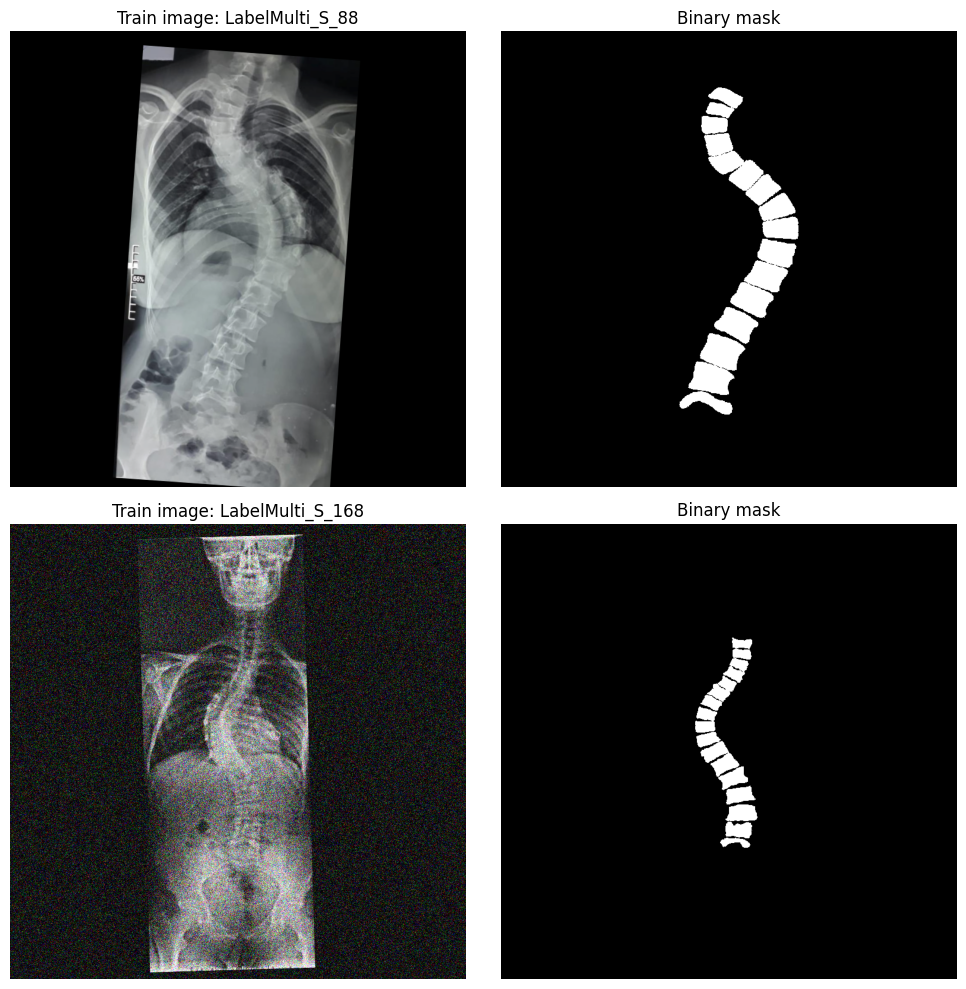

In [12]:
# ============================================================
# 12) Visual sanity check
# ============================================================

def denormalize_image_tensor(image_t: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = image_t.detach().cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)

batch = next(iter(train_loader))
n = min(4, batch["image"].shape[0])

plt.figure(figsize=(10, 5 * n))
for i in range(n):
    image_np = denormalize_image_tensor(batch["image"][i])
    mask_np = batch["mask"][i, 0].detach().cpu().numpy()

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(image_np)
    plt.title(f"Train image: {batch['stem'][i]}")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(mask_np, cmap="gray", vmin=0, vmax=1)
    plt.title("Binary mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 13) Model, loss, metrics
# ============================================================

model = smp.DeepLabV3Plus(
    encoder_name=cfg.ENCODER_NAME,
    encoder_weights=cfg.ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
    activation=None,
).to(DEVICE)

dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
focal_loss_fn = smp.losses.FocalLoss(mode="binary")

def combined_loss(logits, targets):
    dice = dice_loss_fn(logits, targets)
    focal = focal_loss_fn(logits, targets)
    return cfg.DICE_WEIGHT * dice + cfg.FOCAL_WEIGHT * focal

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

def compute_metrics_from_logits(logits, targets, threshold: float = 0.5, eps: float = 1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = targets.float()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
        "foreground_recall": recall.mean().item(),
    }

print(model.__class__.__name__)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

DeepLabV3Plus


/tmp/ipykernel_4063/1237575759.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


In [14]:
# ============================================================
# 14) Training and validation loops
# ============================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    metric_sums = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0, "foreground_recall": 0.0}
    n_batches = 0

    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        metrics = compute_metrics_from_logits(logits.detach(), masks, threshold=cfg.DEFAULT_THRESHOLD)
        for k in metric_sums:
            metric_sums[k] += metrics[k]
        n_batches += 1

    out = {f"train_{k}": v / max(1, n_batches) for k, v in metric_sums.items()}
    out["train_loss"] = running_loss / max(1, n_batches)
    return out

@torch.no_grad()
def validate_one_epoch(model, loader, split_name="val"):
    model.eval()
    running_loss = 0.0
    metric_sums = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0, "foreground_recall": 0.0}
    n_batches = 0

    for batch in tqdm(loader, desc=split_name, leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)

        running_loss += loss.item()
        metrics = compute_metrics_from_logits(logits, masks, threshold=cfg.DEFAULT_THRESHOLD)
        for k in metric_sums:
            metric_sums[k] += metrics[k]
        n_batches += 1

    out = {f"{split_name}_{k}": v / max(1, n_batches) for k, v in metric_sums.items()}
    out[f"{split_name}_loss"] = running_loss / max(1, n_batches)
    return out

In [15]:
# ============================================================
# 15) Train with early stopping
# ============================================================

best_val_dice = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

best_ckpt_path = CHECKPOINT_DIR / "best_model.pth"
last_ckpt_path = CHECKPOINT_DIR / "last_model.pth"
metrics_csv_path = RUN_DIR / "metrics.csv"

for epoch in range(1, cfg.EPOCHS + 1):
    print(f"\nEpoch {epoch}/{cfg.EPOCHS}")

    train_metrics = train_one_epoch(model, train_loader)
    val_metrics = validate_one_epoch(model, val_loader, split_name="val")

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **train_metrics,
        **val_metrics,
    }
    history.append(row)

    val_dice = val_metrics["val_dice"]
    scheduler.step(val_dice)

    pd.DataFrame(history).to_csv(metrics_csv_path, index=False)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "cfg": config_dict,
        "metrics": row,
    }, last_ckpt_path)

    improved = val_dice > best_val_dice
    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "cfg": config_dict,
            "metrics": row,
        }, best_ckpt_path)

        print(f"Saved new best model: val_dice={best_val_dice:.4f}")
    else:
        epochs_without_improvement += 1

    print(json.dumps(row, indent=2))

    if epochs_without_improvement >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val Dice: {best_val_dice:.4f}")
        break

print("Best checkpoint:", best_ckpt_path)
print("Last checkpoint:", last_ckpt_path)
print("Metrics CSV:", metrics_csv_path)


Epoch 1/80


Train:   0%|          | 0/87 [00:00<?, ?it/s]

/tmp/ipykernel_4063/3807418592.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


val:   0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_4063/3807418592.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


...

val:   0%|          | 0/19 [00:00<?, ?it/s]

{
  "epoch": 79,
  "lr": 2.5e-05,
  "train_dice": 0.9356319828965198,
  "train_iou": 0.8798321649946016,
  "train_precision": 0.9254791990093801,
  "train_recall": 0.9465218460422823,
  "train_foreground_recall": 0.9465218460422823,
  "train_loss": 0.045738184631898486,
  "val_dice": 0.9036169773653934,
  "val_iou": 0.8248074305684943,
  "val_precision": 0.9001389647784986,
  "val_recall": 0.908636234308544,
  "val_foreground_recall": 0.908636234308544,
  "val_loss": 0.07239015812152311
}

Epoch 80/80


Train:   0%|          | 0/87 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

{
  "epoch": 80,
  "lr": 2.5e-05,
  "train_dice": 0.9348136837455048,
  "train_iou": 0.878176919345198,
  "train_precision": 0.9246165218024418,
  "train_recall": 0.9457867262007176,
  "train_foreground_recall": 0.9457867262007176,
  "train_loss": 0.04696060935484952,
  "val_dice": 0.9033836126327515,
  "val_iou": 0.8244742531525461,
  "val_precision": 0.8926013708114624,
  "val_recall": 0.9161675791991385,
  "val_foreground_recall": 0.9161675791991385,
  "val_loss": 0.07302746666889441
}
Best checkpoint: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/checkpoints/best_model.pth
Last checkpoint: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/checkpoints/last_model.pth
Metrics 

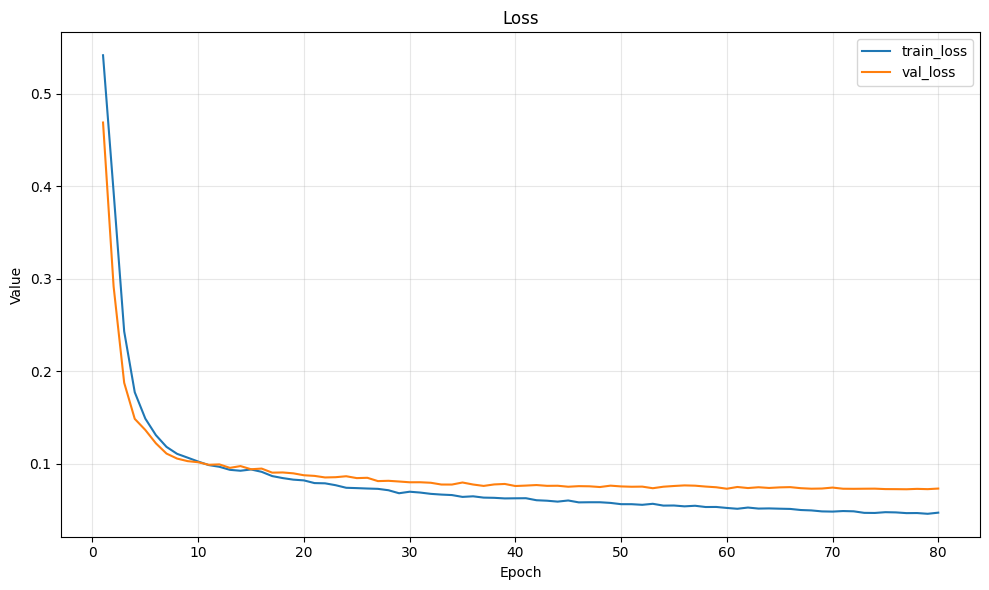

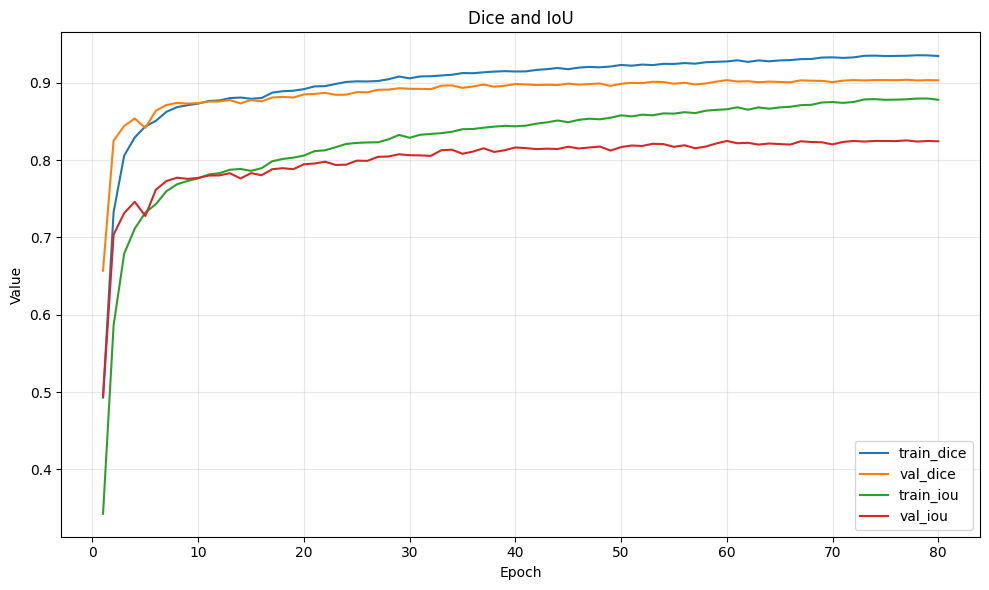

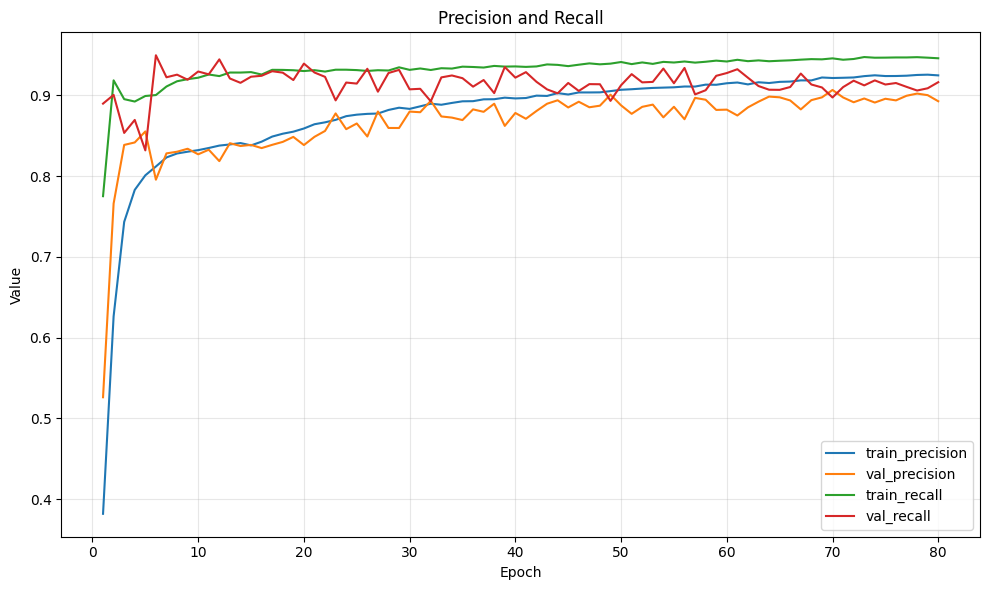

In [16]:
# ============================================================
# 16) Plot loss and metrics
# ============================================================

history_df = pd.read_csv(metrics_csv_path)

def save_metric_plot(y_cols, title, out_path):
    plt.figure(figsize=(10, 6))
    for col in y_cols:
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=col)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

save_metric_plot(["train_loss", "val_loss"], "Loss", PLOTS_DIR / "loss.png")
save_metric_plot(["train_dice", "val_dice", "train_iou", "val_iou"], "Dice and IoU", PLOTS_DIR / "dice_iou.png")
save_metric_plot(["train_precision", "val_precision", "train_recall", "val_recall"], "Precision and Recall", PLOTS_DIR / "precision_recall.png")

In [17]:
# ============================================================
# 17) Load best model
# ============================================================

checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Best checkpoint metrics:")
print(json.dumps(checkpoint["metrics"], indent=2))

Loaded best checkpoint from epoch: 77
Best checkpoint metrics:
{
  "epoch": 77,
  "lr": 2.5e-05,
  "train_dice": 0.9351270959295076,
  "train_iou": 0.878756080550709,
  "train_precision": 0.9242060979207357,
  "train_recall": 0.946793896713476,
  "train_foreground_recall": 0.946793896713476,
  "train_loss": 0.04645979965383979,
  "val_dice": 0.9040870384166115,
  "val_iou": 0.8256239514601859,
  "val_precision": 0.8993784691158094,
  "val_recall": 0.9104268644985399,
  "val_foreground_recall": 0.9104268644985399,
  "val_loss": 0.07226808565227609
}


In [18]:
# ============================================================
# 18) Overlay helpers
# ============================================================

def resize_binary_to_shape(mask: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    return cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)

def longest_maxsize_pad_meta(h: int, w: int, image_size: int):
    scale = image_size / max(h, w)
    resized_h = int(round(h * scale))
    resized_w = int(round(w * scale))

    pad_top = (image_size - resized_h) // 2
    pad_left = (image_size - resized_w) // 2

    return resized_h, resized_w, pad_top, pad_left


def restore_prob_from_padded_canvas(prob_canvas: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    resized_h, resized_w, pad_top, pad_left = longest_maxsize_pad_meta(target_h, target_w, cfg.IMAGE_SIZE)

    prob_unpadded = prob_canvas[
        pad_top:pad_top + resized_h,
        pad_left:pad_left + resized_w,
    ]

    prob_restored = cv2.resize(
        prob_unpadded.astype(np.float32),
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR,
    )

    return prob_restored

def overlay_mask_on_image(image_rgb: np.ndarray, binary_mask: np.ndarray, color_rgb=(242, 209, 12), alpha=0.35) -> np.ndarray:
    overlay = image_rgb.copy().astype(np.float32)
    color = np.array(color_rgb, dtype=np.float32)
    mask_bool = binary_mask.astype(bool)
    overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * color
    return np.clip(overlay, 0, 255).astype(np.uint8)

@torch.no_grad()
def predict_tensor(image_t: torch.Tensor, threshold: float = 0.5):
    model.eval()
    image_t = image_t.unsqueeze(0).to(DEVICE)
    with autocast(enabled=(DEVICE.type == "cuda")):
        logits = model(image_t)
    prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    pred = (prob >= threshold).astype(np.uint8)
    return prob, pred

In [ ]:
# ============================================================
# 19) Save sample validation/test overlays
# ============================================================

def save_sample_overlays(df: pd.DataFrame, out_dir: Path, max_items: int = 12, threshold: float = 0.5):
    out_dir.mkdir(parents=True, exist_ok=True)
    valid_tfms = get_valid_transforms()

    rows = []
    for _, row in tqdm(df.head(max_items).iterrows(), total=min(max_items, len(df)), desc=f"Saving overlays to {out_dir.name}"):
        image_orig = read_image_rgb(Path(row["image_path"]))
        id_mask_orig = read_id_mask(Path(row["mask_path"]))
        true_binary_orig = (id_mask_orig > 0).astype(np.uint8)

        image_crop, mask_crop, crop_meta = apply_crop_if_needed(image_orig, true_binary_orig)
        transformed = valid_tfms(image=image_crop, mask=mask_crop)
        image_t = transformed["image"]
        prob_resized, pred_resized = predict_tensor(image_t, threshold=threshold)

        # Prediction is in padded square canvas. Remove padding first, then restore.
        crop_h, crop_w = image_crop.shape[:2]
        prob_crop = restore_prob_from_padded_canvas(prob_resized, crop_h, crop_w)
        pred_crop = (prob_crop >= threshold).astype(np.uint8)

        if cfg.CROP_MODE == "central":
            pred_full = paste_crop_prediction_back(pred_crop, crop_meta)
        else:
            pred_full = pred_crop

        overlay_pred = overlay_mask_on_image(image_orig, pred_full, cfg.BRIGHT_MASK_RGB, cfg.OVERLAY_ALPHA)
        overlay_true = overlay_mask_on_image(image_orig, true_binary_orig, (0, 255, 0), cfg.OVERLAY_ALPHA)

        stem = row["stem"]
        pred_path = out_dir / f"{stem}_pred_overlay_thr{threshold:.2f}.png"
        true_path = out_dir / f"{stem}_true_overlay.png"
        pred_mask_path = out_dir / f"{stem}_pred_binary_0_1.png"

        Image.fromarray(overlay_pred).save(pred_path)
        Image.fromarray(overlay_true).save(true_path)
        Image.fromarray(pred_full.astype(np.uint8)).save(pred_mask_path)

        rows.append({
            "stem": stem,
            "pred_overlay": str(pred_path),
            "true_overlay": str(true_path),
            "pred_mask_0_1": str(pred_mask_path),
            "threshold": threshold,
            "pred_fg_pixels": int(pred_full.sum()),
            "true_fg_pixels": int(true_binary_orig.sum()),
        })

    summary_df = pd.DataFrame(rows)
    summary_path = out_dir / "overlay_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print("Saved summary:", summary_path)
    display(summary_df.head())
    return summary_df

val_overlay_df = save_sample_overlays(val_df, SAMPLE_VAL_DIR, max_items=12, threshold=cfg.DEFAULT_THRESHOLD)
test_overlay_df = save_sample_overlays(test_df, SAMPLE_TEST_DIR, max_items=12, threshold=cfg.DEFAULT_THRESHOLD)

In [20]:
# ============================================================
# 20) Final test evaluation
# ============================================================

test_metrics = validate_one_epoch(model, test_loader, split_name="test")
test_metrics_path = RUN_DIR / "test_metrics.json"

with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

print(json.dumps(test_metrics, indent=2))
print("Saved test metrics:", test_metrics_path)

test:   0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_4063/3807418592.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


{
  "test_dice": 0.8963854846201444,
  "test_iou": 0.8131490067431801,
  "test_precision": 0.8965086623242027,
  "test_recall": 0.8990943839675501,
  "test_foreground_recall": 0.8990943839675501,
  "test_loss": 0.0789403552679639
}
Saved test metrics: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/test_metrics.json


In [21]:
# ============================================================
# 21) Inference preprocessing for new JPEG images
# ============================================================

def list_new_images(new_images_dir):
    new_images_dir = Path(new_images_dir)
    exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
    return sorted([
        p for p in new_images_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in exts
    ])

def preprocess_new_image_for_model(image_rgb: np.ndarray):
    # No mask exists here, but reuse same crop/resize/pad transform.
    image_crop, _, crop_meta = apply_crop_if_needed(image_rgb, None)

    tfm = A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
        ),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])

    transformed = tfm(image=image_crop)
    return transformed["image"], image_crop, crop_meta

@torch.no_grad()
def predict_new_image_full_size(image_rgb: np.ndarray, threshold: float):
    image_t, image_crop, crop_meta = preprocess_new_image_for_model(image_rgb)
    prob_canvas, _ = predict_tensor(image_t, threshold=threshold)

    crop_h, crop_w = image_crop.shape[:2]
    prob_crop = restore_prob_from_padded_canvas(prob_canvas, crop_h, crop_w)
    pred_crop = (prob_crop >= threshold).astype(np.uint8)

    if cfg.CROP_MODE == "central":
        pred_full = paste_crop_prediction_back(pred_crop, crop_meta)

        prob_full = np.zeros((crop_meta["orig_h"], crop_meta["orig_w"]), dtype=np.float32)
        x0, y0, x1, y1 = crop_meta["x0"], crop_meta["y0"], crop_meta["x1"], crop_meta["y1"]
        prob_full[y0:y1, x0:x1] = prob_crop
    else:
        pred_full = pred_crop
        prob_full = prob_crop

    return prob_full, pred_full

def make_bright_binary_color_mask(binary_mask: np.ndarray, color_rgb=(242, 209, 12)) -> np.ndarray:
    out = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    out[binary_mask.astype(bool)] = np.array(color_rgb, dtype=np.uint8)
    return out

def save_probability_heatmap(prob: np.ndarray, out_path: Path):
    plt.figure(figsize=(8, 10))
    plt.imshow(prob, cmap="magma", vmin=0, vmax=1)
    plt.colorbar()
    plt.title("Probability heatmap")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()

In [22]:
# ============================================================
# 22) Run inference on new JPEG images with threshold comparisons
# ============================================================

new_image_paths = list_new_images(cfg.NEW_IMAGES_DIR)

debug_dir = Path(cfg.NEW_IMAGES_DIR)
print("Folder exists:", debug_dir.exists())
print("Direct folder items:", [p.name for p in debug_dir.glob("*")][:30])
print("Recursive image files:", [p.name for p in new_image_paths][:30])

print("NEW_IMAGES_DIR:", cfg.NEW_IMAGES_DIR)
print("Found new images:", len(new_image_paths))
for p in new_image_paths:
    print(" -", p.name)

assert len(new_image_paths) > 0, (
    "No new images found. Update cfg.NEW_IMAGES_DIR in the configuration cell "
    "or place your 10 JPEGs in that folder."
)

id_mask_dir = INFERENCE_DIR / "pred_binary_id_masks_0_1"
color_mask_dir = INFERENCE_DIR / "pred_bright_color_masks"
overlay_dir = INFERENCE_DIR / "overlays"
heatmap_dir = INFERENCE_DIR / "probability_heatmaps"
comparison_dir = INFERENCE_DIR / "threshold_comparisons"
original_copy_dir = INFERENCE_DIR / "original_copies"

for p in [id_mask_dir, color_mask_dir, overlay_dir, heatmap_dir, comparison_dir, original_copy_dir]:
    p.mkdir(parents=True, exist_ok=True)

rows = []

for image_path in tqdm(new_image_paths, desc="New JPEG inference"):
    image_rgb = read_image_rgb(image_path)
    stem = image_path.stem

    original_copy_path = original_copy_dir / image_path.name
    shutil.copy2(image_path, original_copy_path)

    # Compute probability once; threshold several times.
    prob_full, _ = predict_new_image_full_size(image_rgb, threshold=cfg.DEFAULT_THRESHOLD)

    heatmap_path = heatmap_dir / f"{stem}_probability_heatmap.png"
    save_probability_heatmap(prob_full, heatmap_path)

    comparison_overlays = []

    for thr in cfg.THRESHOLDS:
        pred_full = (prob_full >= thr).astype(np.uint8)

        id_mask_path = id_mask_dir / f"{stem}_pred_binary_0_1_thr{thr:.2f}.png"
        color_mask_path = color_mask_dir / f"{stem}_bright_yellow_thr{thr:.2f}.png"
        overlay_path = overlay_dir / f"{stem}_overlay_thr{thr:.2f}.png"

        Image.fromarray(pred_full.astype(np.uint8)).save(id_mask_path, format="PNG", compress_level=0)
        Image.fromarray(make_bright_binary_color_mask(pred_full, cfg.BRIGHT_MASK_RGB)).save(color_mask_path, format="PNG", compress_level=0)
        Image.fromarray(overlay_mask_on_image(image_rgb, pred_full, cfg.BRIGHT_MASK_RGB, cfg.OVERLAY_ALPHA)).save(overlay_path)

        comparison_overlays.append((thr, overlay_path))

        rows.append({
            "source_image_path": str(image_path),
            "original_copy_path": str(original_copy_path),
            "threshold": thr,
            "pred_binary_id_mask_0_1_path": str(id_mask_path),
            "pred_bright_color_mask_path": str(color_mask_path),
            "overlay_path": str(overlay_path),
            "probability_heatmap_path": str(heatmap_path),
            "image_h": int(image_rgb.shape[0]),
            "image_w": int(image_rgb.shape[1]),
            "pred_fg_pixels": int(pred_full.sum()),
            "crop_mode": cfg.CROP_MODE,
        })

    # Save a side-by-side threshold comparison PNG.
    fig, axes = plt.subplots(1, len(comparison_overlays), figsize=(5 * len(comparison_overlays), 7))
    if len(comparison_overlays) == 1:
        axes = [axes]

    for ax, (thr, overlay_path) in zip(axes, comparison_overlays):
        ax.imshow(np.array(Image.open(overlay_path).convert("RGB")))
        ax.set_title(f"threshold={thr:.2f}")
        ax.axis("off")

    comparison_path = comparison_dir / f"{stem}_threshold_comparison.png"
    plt.tight_layout()
    plt.savefig(comparison_path, dpi=160)
    plt.close()

inference_df = pd.DataFrame(rows)
inference_csv_path = INFERENCE_DIR / "new_jpeg_inference_summary.csv"
inference_df.to_csv(inference_csv_path, index=False)

print("Saved inference summary:", inference_csv_path)
print("ID masks:", id_mask_dir)
print("Bright color masks:", color_mask_dir)
print("Overlays:", overlay_dir)
print("Threshold comparisons:", comparison_dir)
display(inference_df.head())

Folder exists: True
Direct folder items: ['1.jpeg', '2.jpeg', '3.jpeg', '4.jpeg', '5.jpeg', '6.jpeg', '7.jpeg', '8.jpeg', '9.jpeg', '10.jpeg']
Recursive image files: ['1.jpeg', '10.jpeg', '2.jpeg', '3.jpeg', '4.jpeg', '5.jpeg', '6.jpeg', '7.jpeg', '8.jpeg', '9.jpeg']
NEW_IMAGES_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_jpeg_images_for_binary_premask
Found new images: 10
 - 1.jpeg
 - 10.jpeg
 - 2.jpeg
 - 3.jpeg
 - 4.jpeg
 - 5.jpeg
 - 6.jpeg
 - 7.jpeg
 - 8.jpeg
 - 9.jpeg


New JPEG inference:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_4063/4076543806.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


Saved inference summary: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/inference_new_jpegs/new_jpeg_inference_summary.csv
ID masks: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/inference_new_jpegs/pred_binary_id_masks_0_1
Bright color masks: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/inference_new_jpegs/pred_bright_color_masks
Overlays: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_pr

,source_image_path,original_copy_path,threshold,pred_binary_id_mask_0_1_path,pred_bright_color_mask_path,overlay_path,probability_heatmap_path,image_h,image_w,pred_fg_pixels,crop_mode
0,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,0.3,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,985,526,29032,full
1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,0.4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,985,526,28395,full
2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,0.5,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,985,526,27834,full
3,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,0.6,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,985,526,27273,full
4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,0.3,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,732,60149,full


In [ ]:
# ============================================================
# 23) Final artifact summary
# ============================================================

final_summary = {
    "experiment_name": cfg.EXPERIMENT_NAME,
    "run_dir": str(RUN_DIR),
    "architecture": cfg.ARCHITECTURE,
    "encoder_name": cfg.ENCODER_NAME,
    "encoder_weights": cfg.ENCODER_WEIGHTS,
    "best_checkpoint": str(best_ckpt_path),
    "last_checkpoint": str(last_ckpt_path),
    "config_json": str(config_path),
    "all_pairs_validation_csv": str(pairs_csv_path),
    "usable_pairs_csv": str(usable_csv_path),
    "split_csv": str(split_csv_path),
    "metrics_csv": str(metrics_csv_path),
    "test_metrics_json": str(test_metrics_path),
    "plots_dir": str(PLOTS_DIR),
    "sample_validation_overlays": str(SAMPLE_VAL_DIR),
    "sample_test_overlays": str(SAMPLE_TEST_DIR),
    "inference_output_dir": str(INFERENCE_DIR),
    "new_jpeg_inference_summary": str(inference_csv_path) if "inference_csv_path" in globals() else None,
    "new_images_dir": str(cfg.NEW_IMAGES_DIR),
    "crop_mode": cfg.CROP_MODE,
    "thresholds": list(cfg.THRESHOLDS),
    "default_threshold": cfg.DEFAULT_THRESHOLD,
}

final_summary_path = RUN_DIR / "final_artifact_summary.json"
with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(final_summary, indent=2, ensure_ascii=False))
print("Saved final summary:", final_summary_path)